In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightkurve import search_lightcurvefile


c:\Users\Novachrono-Grimm\AppData\Local\Programs\Python\Python310\lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


C:\Users\Novachrono-Grimm\AppData\Local\Temp\ipykernel_8360\4280269939.py:1: LightkurveDeprecationWarning: The search_lightcurvefile function is deprecated and may be removed in a future version.
        Use search_lightcurve() instead.
  lcfile = search_lightcurvefile('Kepler-90', mission='Kepler', quarter=16).download()


Using SAP_FLUX


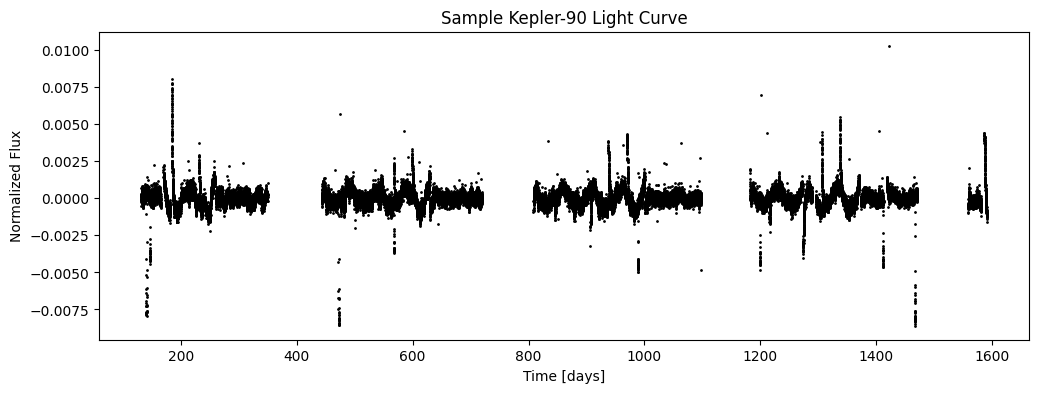

In [3]:
lcfile = search_lightcurvefile('Kepler-90', mission='Kepler', quarter=16).download()

# Check which flux column exists
if hasattr(lcfile, 'pdcsap_flux') and lcfile.pdcsap_flux is not None:
    flux = lcfile.pdcsap_flux
    print("Using PDCSAP_FLUX")
elif hasattr(lcfile, 'sap_flux') and lcfile.sap_flux is not None:
    flux = lcfile.sap_flux
    print("Using SAP_FLUX")
else:
    raise ValueError("No usable flux column found in this light curve.")

# Time array
time = lcfile.time.value

# Remove NaNs
mask = ~np.isnan(flux)
time = time[mask]
flux = flux[mask]

# Normalize and flatten
flux = flux / np.median(flux) - 1

# Plot
plt.figure(figsize=(12,4))
plt.plot(time, flux, 'k.', markersize=2)
plt.xlabel("Time [days]")
plt.ylabel("Normalized Flux")
plt.title("Sample Kepler-90 Light Curve")
plt.show()

In [4]:
# Sliding window approach for creating sequences
window_size = 200  # number of points per sample
X, y = [], []

for i in range(len(flux) - window_size):
    X.append(flux[i:i+window_size])
    # Simple labeling: dips below 0.999 are transit candidates (toy example)
    y.append(1 if np.min(flux[i:i+window_size]) < 0.999 else 0)

X = np.array(X)
y = np.array(y)

# Reshape for CNN input
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(window_size,1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\Novachrono-Grimm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       192,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,137 (793.50 KB)

 Trainable params: 203,137 (793.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9996 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 1.4119e-10
Epoch 2/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 1.0000 - loss: 2.9494e-07 - val_accuracy: 1.0000 - val_loss: 9.7301e-13
Epoch 3/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 1.0000 - loss: 3.3268e-08 - val_accuracy: 1.0000 - val_loss: 1.7959e-13
Epoch 4/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 1.0000 - loss: 1.9639e-08 - val_accuracy: 1.0000 - val_loss: 4.4412e-14
Epoch 5/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 1.0000 - loss: 7.6743e-08 - val_accuracy: 1.0000 - val_loss: 2.3152e-15
Epoch 6/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 1.0000 - loss: 4.3453e-09 - val_accuracy: 1.0000 - val_loss: 1.3791e-15
Epoch 7/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 1.0000 - loss: 1.0631e-08 - val_accuracy: 1.0000 - val_loss: 4.7151e-16
Epoch 8/10
1007/1007 ━━━

315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 2.3958e-17
Test Accuracy: 100.00%


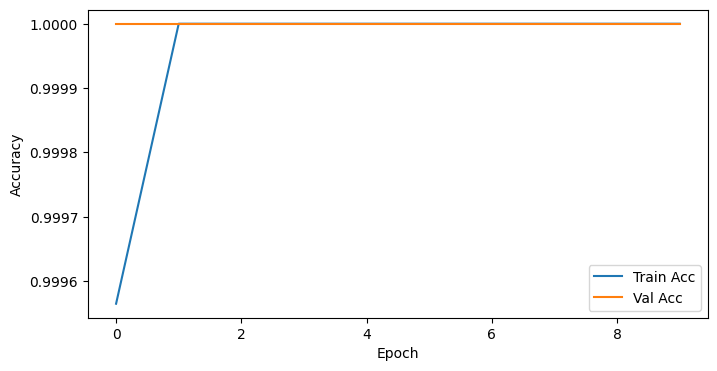

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Plot training & validation accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


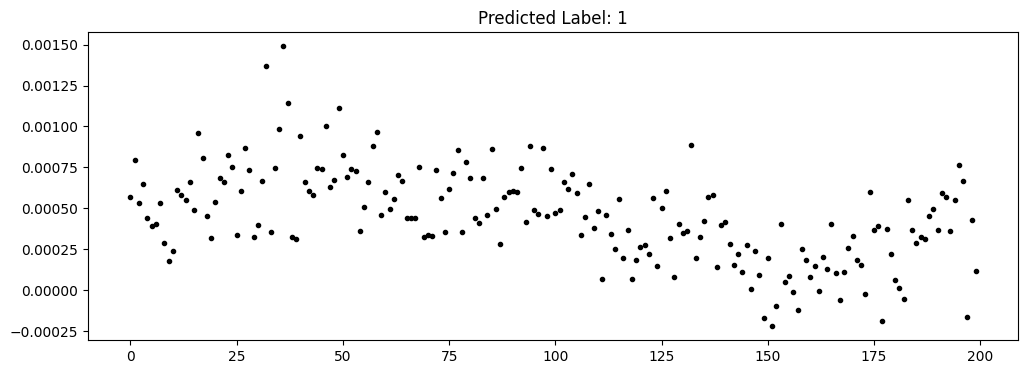

In [8]:
preds = model.predict(X_test)
pred_labels = (preds > 0.5).astype(int)

# Plot a sample light curve with predicted transit
plt.figure(figsize=(12,4))
plt.plot(X_test[0].reshape(-1), 'k.')
plt.title(f"Predicted Label: {pred_labels[0][0]}")
plt.show()

In [9]:
print(time[:20])

[131.51243654 131.53287085 131.55330505 131.57373916 131.59417336
 131.61460767 131.63504177 131.65547598 131.67591028 131.69634449
 131.71677859 131.7372128  131.7576471  131.77808121 131.79851541
 131.81894972 131.83938382 131.85981803 131.88025223 131.90068644]


In [10]:
print(flux[:20])


[-1.21757541e-04  1.54780991e-04  1.25959494e-04 -1.04832614e-04
  1.43503407e-04 -1.81895417e-04  1.58497616e-04  7.26736552e-04
 -3.34397301e-05 -4.91250556e-04 -2.35014225e-04  3.13686346e-04
  1.03551531e-04  3.75712568e-05  2.66869205e-04 -3.15011776e-05
  1.98553944e-04 -1.26470000e-04  5.97347178e-05  1.73413834e-04]


In [11]:
print(len(time), len(flux))


50505 50505


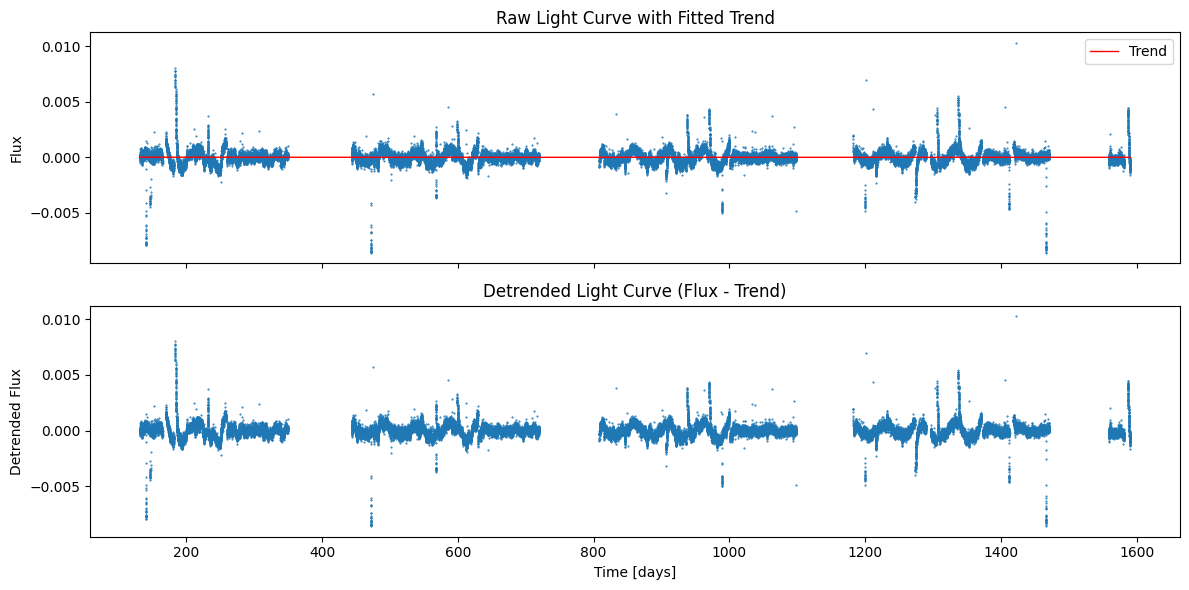

In [ ]:
time_raw = time.copy()
flux_raw = flux.copy()

# Fit a low-order polynomial as a simple trend model
z = np.polyfit(time_raw, flux_raw, deg=3)
trend = np.polyval(z, time_raw)

flux_detrended = flux_raw - trend  # high-pass version

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(time_raw, flux_raw, '.', markersize=1)
ax[0].plot(time_raw, trend, 'r-', linewidth=1, label='Trend')
ax[0].set_ylabel("Flux")
ax[0].set_title("Raw Light Curve with Fitted Trend")
ax[0].legend()

ax[1].plot(time_raw, flux_detrended, '.', markersize=1)
ax[1].set_xlabel("Time [days]")
ax[1].set_ylabel("Detrended Flux")
ax[1].set_title("Detrended Light Curve (Flux - Trend)")

plt.tight_layout()
plt.show()


Estimated period ~ 46.495675428876766 days


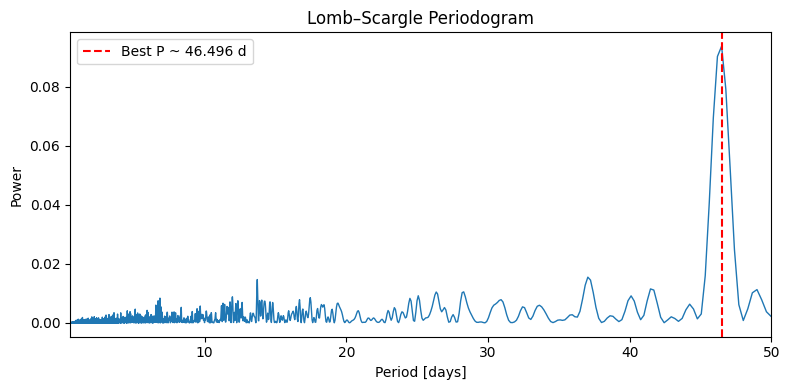

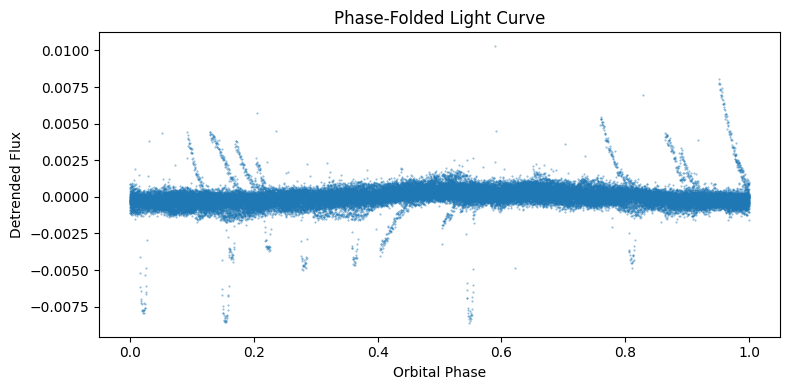

In [14]:
from astropy.timeseries import LombScargle
# Use Lomb-Scargle to estimate likely period
min_period = 0.5   # days
max_period = 50.0  # days (you can tweak)
frequency, power = LombScargle(time_raw, flux_detrended).autopower(
    minimum_frequency=1/max_period,
    maximum_frequency=1/min_period
)

best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency
print("Estimated period ~", best_period, "days")

# Plot the periodogram
plt.figure(figsize=(8,4))
plt.plot(1/frequency, power, '-', linewidth=1)
plt.axvline(best_period, color='r', linestyle='--', label=f'Best P ~ {best_period:.3f} d')
plt.xlim(min_period, max_period)
plt.xlabel("Period [days]")
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram")
plt.legend()
plt.tight_layout()
plt.show()

# Phase-fold the detrended light curve
phase = (time_raw % best_period) / best_period
order = np.argsort(phase)
phase_sorted = phase[order]
flux_phase_sorted = flux_detrended[order]

plt.figure(figsize=(8,4))
plt.plot(phase_sorted, flux_phase_sorted, '.', markersize=1, alpha=0.5)
plt.xlabel("Orbital Phase")
plt.ylabel("Detrended Flux")
plt.title("Phase-Folded Light Curve")
plt.tight_layout()
plt.show()


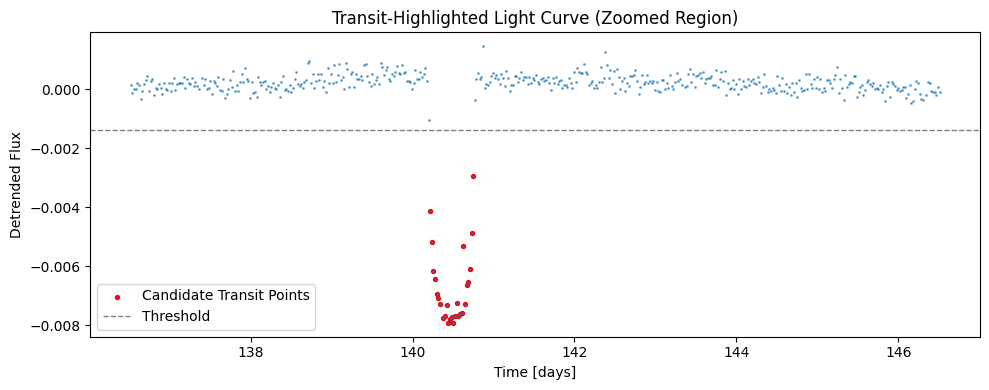

In [15]:
# Simple thresholding to mark candidate in-transit points
mu = np.median(flux_detrended)
sigma = np.std(flux_detrended)
threshold = mu - 2*sigma   # points below this considered "dip"

in_transit = flux_detrended < threshold

# Pick a time window to zoom in (adjust if needed)
tmin, tmax = time_raw[0] + 5, time_raw[0] + 15
mask_zoom = (time_raw > tmin) & (time_raw < tmax)

plt.figure(figsize=(10,4))
plt.plot(time_raw[mask_zoom], flux_detrended[mask_zoom], '.', markersize=2, alpha=0.6)
plt.scatter(time_raw[mask_zoom][in_transit[mask_zoom]],
            flux_detrended[mask_zoom][in_transit[mask_zoom]],
            color='red', s=8, label='Candidate Transit Points')
plt.axhline(threshold, color='gray', linestyle='--', linewidth=1, label='Threshold')
plt.xlabel("Time [days]")
plt.ylabel("Detrended Flux")
plt.title("Transit-Highlighted Light Curve (Zoomed Region)")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
window_size = 128
step = window_size // 2  # overlap

X = []
y = []

for start in range(0, len(time_raw) - window_size, step):
    end = start + window_size
    window_flux = flux_detrended[start:end]
    window_in_transit = in_transit[start:end]
    
    label = 1 if np.mean(window_in_transit) > 0.15 else 0
    X.append(window_flux)
    y.append(label)

X = np.array(X)
y = np.array(y)
X = X[..., np.newaxis]  # (samples, timesteps, channels)

print("Dataset shape:", X.shape, "Labels:", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


Dataset shape: (788, 128, 1) Labels: [766  22]


In [17]:
model = Sequential([
    Conv1D(16, kernel_size=5, activation='relu', input_shape=(window_size, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\Novachrono-Grimm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 124, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 62, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 58, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 27, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 832)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,273 (243.25 KB)

 Trainable params: 62,273 (243.25 KB)

 Non-trainable params: 0 (0.00 B)

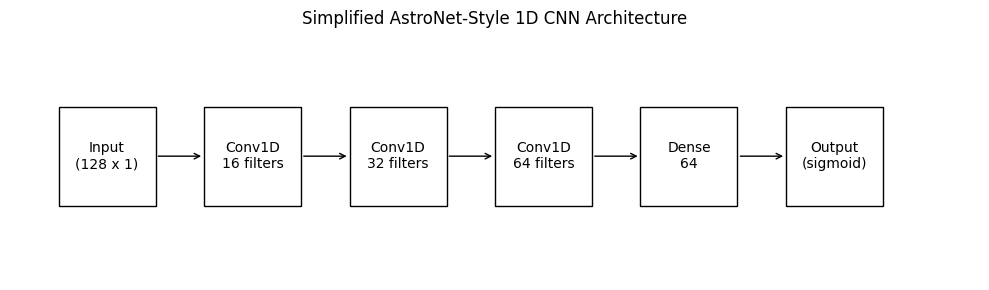

In [18]:
fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

blocks = [
    ("Input\n(128 x 1)", 0.1),
    ("Conv1D\n16 filters", 0.25),
    ("Conv1D\n32 filters", 0.4),
    ("Conv1D\n64 filters", 0.55),
    ("Dense\n64", 0.7),
    ("Output\n(sigmoid)", 0.85),
]

for text, x in blocks:
    rect = plt.Rectangle((x-0.05, 0.3), 0.1, 0.4, fill=False)
    ax.add_patch(rect)
    ax.text(x, 0.5, text, ha='center', va='center')

for i in range(len(blocks)-1):
    x1 = blocks[i][1] + 0.05
    x2 = blocks[i+1][1] - 0.05
    ax.annotate("", xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_title("Simplified AstroNet-Style 1D CNN Architecture")
plt.tight_layout()
plt.show()


In [19]:
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9110 - loss: 0.6200 - val_accuracy: 0.9748 - val_loss: 0.4448
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9703 - loss: 0.2535 - val_accuracy: 0.9748 - val_loss: 0.1184
Epoch 3/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9703 - loss: 0.1562 - val_accuracy: 0.9748 - val_loss: 0.1299
Epoch 4/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9703 - loss: 0.1396 - val_accuracy: 0.9748 - val_loss: 0.1214
Epoch 5/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9703 - loss: 0.1482 - val_accuracy: 0.9748 - val_loss: 0.1180
Epoch 6/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9703 - loss: 0.1323 - val_accuracy: 0.9748 - val_loss: 0.1178
Epoch 7/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9703 - loss: 0.1406 - val_accuracy: 0.9748 - val_loss: 0.1176
Epoch 8/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9703 - loss: 0.1414 - val_accuracy: 0.9748 - val_loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


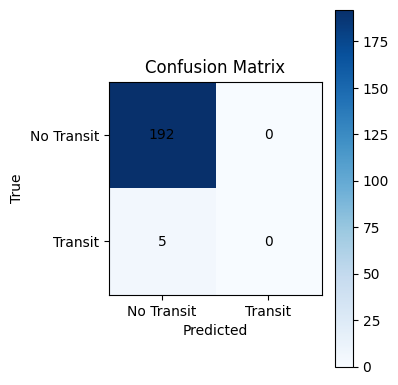

In [25]:
import itertools
from sklearn.metrics import confusion_matrix
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['No Transit', 'Transit'])
ax.set_yticklabels(['No Transit', 'Transit'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title("Confusion Matrix")

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


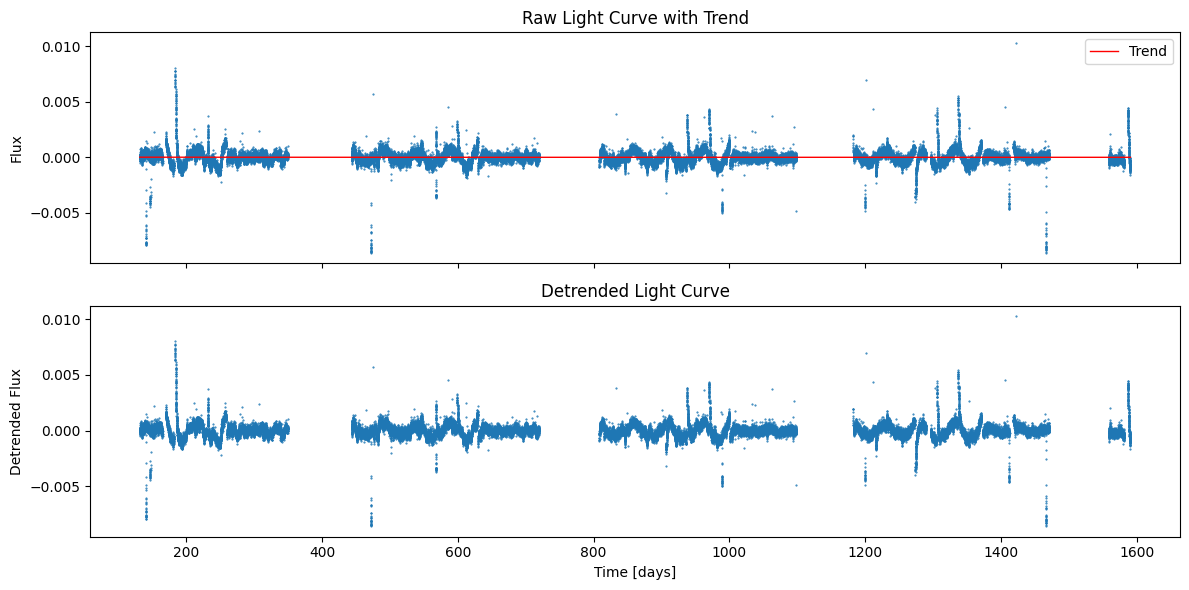

Estimated period: 46.495675428876766 days


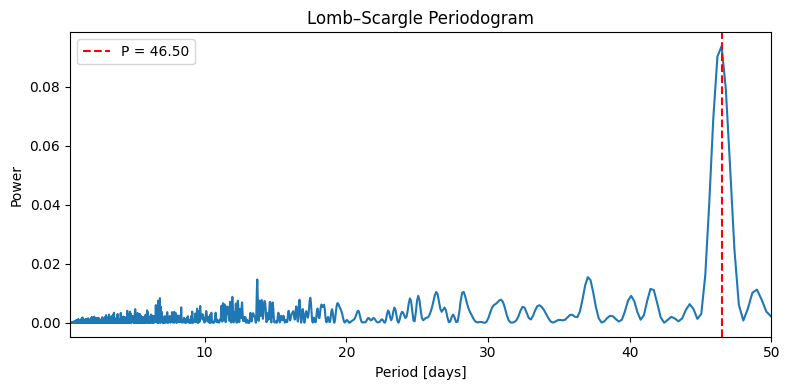

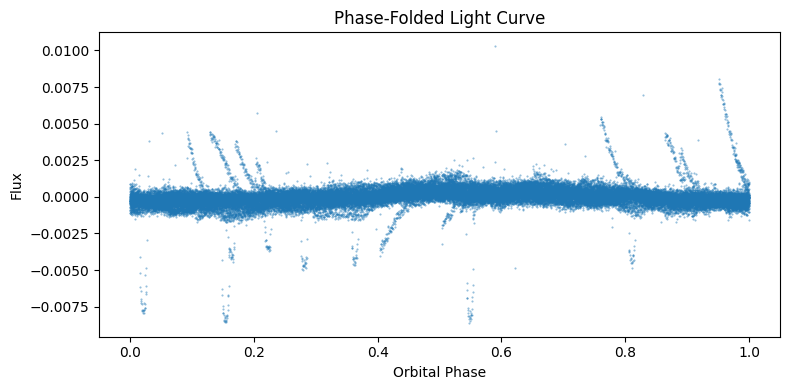

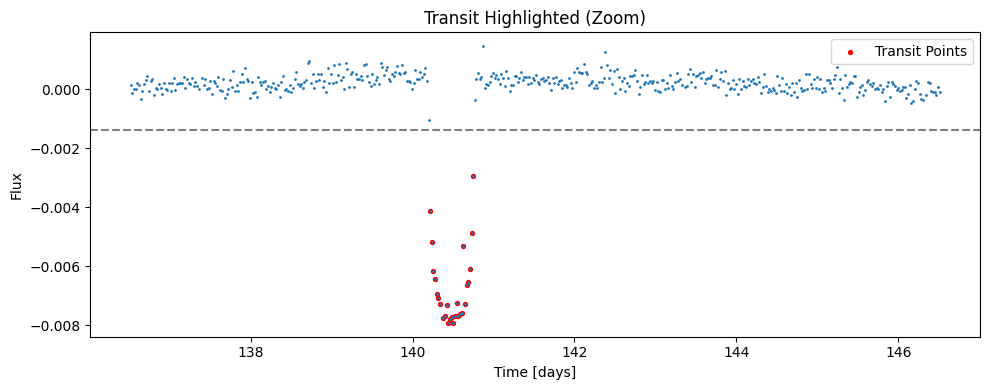

Dataset: (788, 128, 1) Labels: [766  22]


c:\Users\Novachrono-Grimm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 124, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 62, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 58, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 27, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 832)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,273 (243.25 KB)

 Trainable params: 62,273 (243.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9597 - loss: 0.5522 - val_accuracy: 0.9748 - val_loss: 0.2296
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9703 - loss: 0.1550 - val_accuracy: 0.9748 - val_loss: 0.1516
Epoch 3/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9703 - loss: 0.1637 - val_accuracy: 0.9748 - val_loss: 0.1183
Epoch 4/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9703 - loss: 0.1426 - val_accuracy: 0.9748 - val_loss: 0.1186
Epoch 5/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9703 - loss: 0.1404 - val_accuracy: 0.9748 - val_loss: 0.1186
Epoch 6/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9703 - loss: 0.1465 - val_accuracy: 0.9748 - val_loss: 0.1176
Epoch 7/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9703 - loss: 0.1378 - val_accuracy: 0.9748 - val_loss: 0.1174
Epoch 8/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9703 - loss: 0.1437 - val_accuracy: 0.9748 - val_loss:

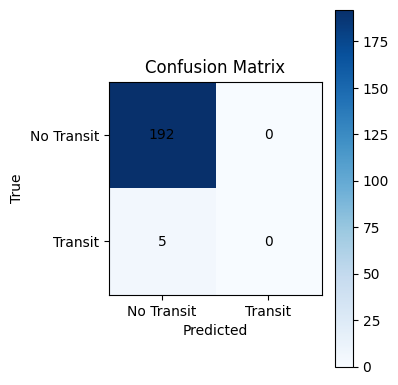

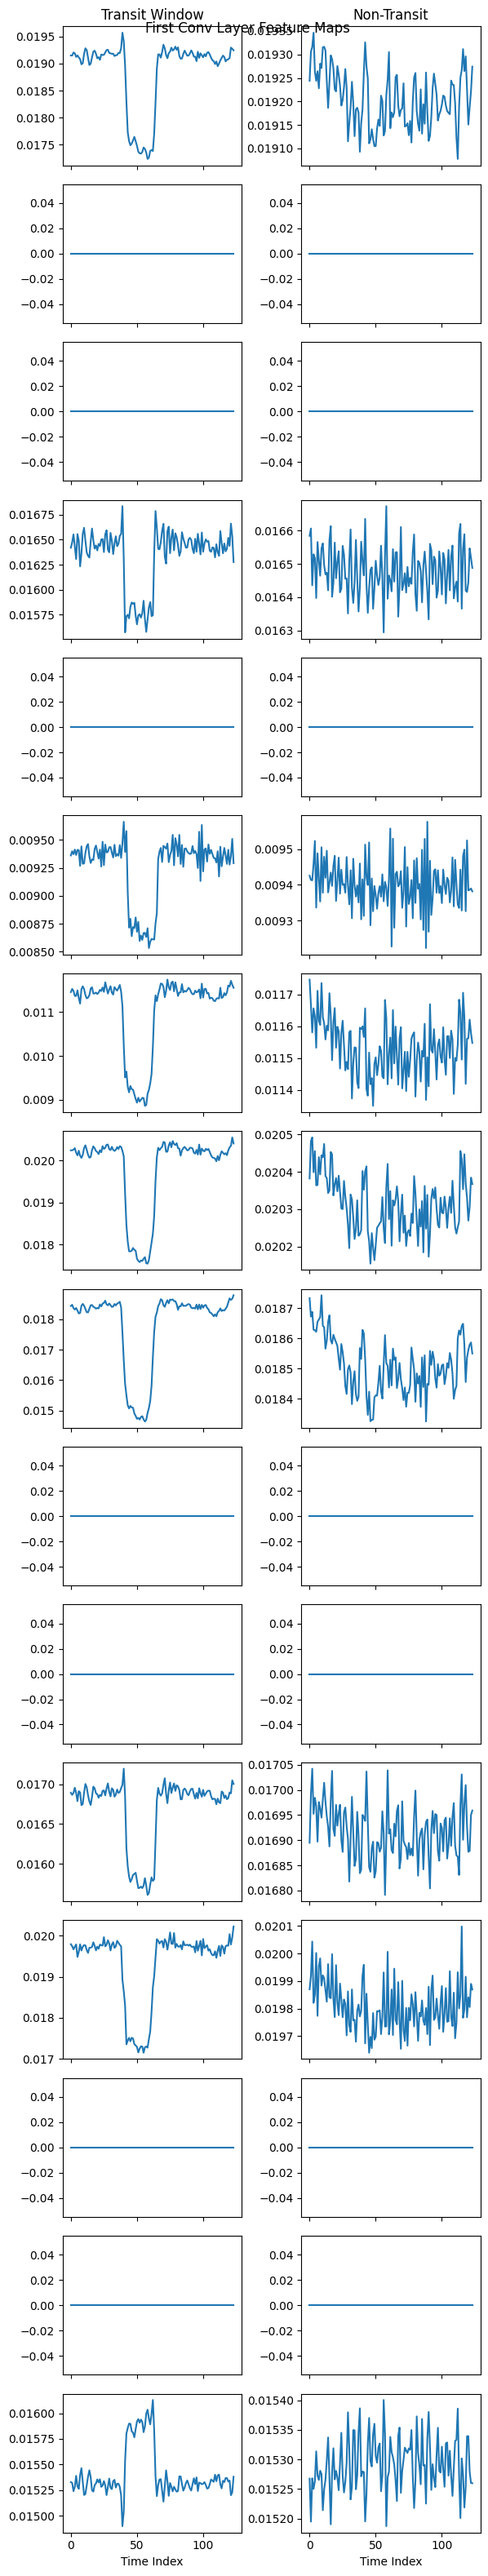

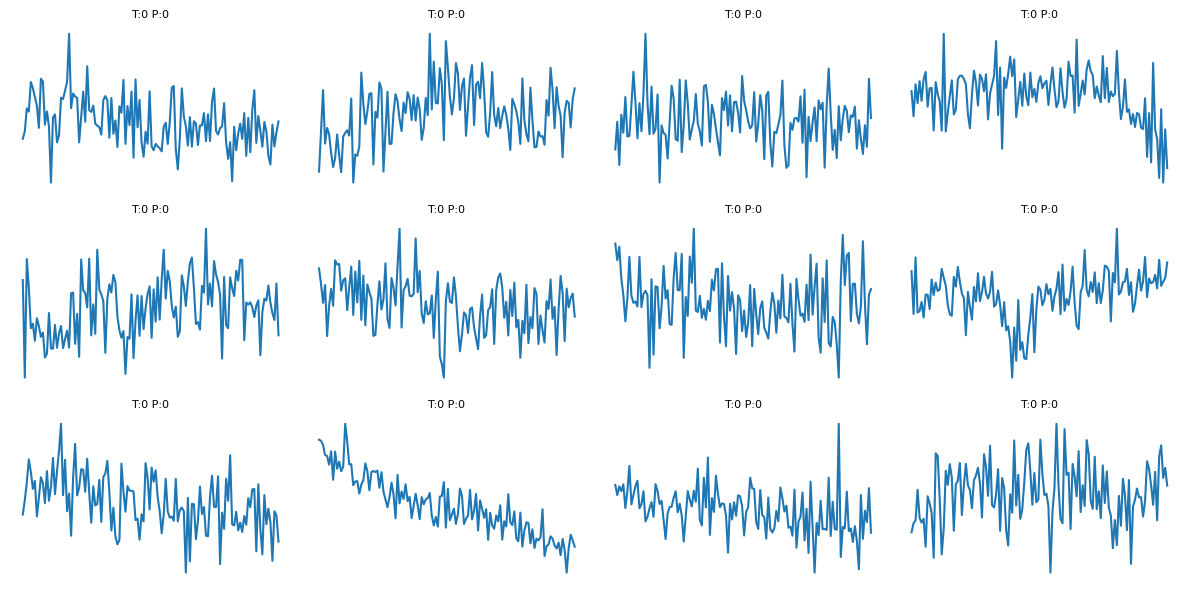

In [30]:
time_raw = time.copy()
flux_raw = flux.copy()

z = np.polyfit(time_raw, flux_raw, deg=3)
trend = np.polyval(z, time_raw)
flux_detrended = flux_raw - trend

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(time_raw, flux_raw, '.', markersize=1)
ax[0].plot(time_raw, trend, 'r-', linewidth=1, label='Trend')
ax[0].set_ylabel("Flux")
ax[0].set_title("Raw Light Curve with Trend")
ax[0].legend()

ax[1].plot(time_raw, flux_detrended, '.', markersize=1)
ax[1].set_xlabel("Time [days]")
ax[1].set_ylabel("Detrended Flux")
ax[1].set_title("Detrended Light Curve")

plt.tight_layout()
plt.show()


# ===============================================
# 3. ESTIMATE PERIOD + PHASE-FOLD
# ===============================================

min_period = 0.5
max_period = 50.0

frequency, power = LombScargle(time_raw, flux_detrended).autopower(
    minimum_frequency=1/max_period,
    maximum_frequency=1/min_period
)

best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print("Estimated period:", best_period, "days")

plt.figure(figsize=(8,4))
plt.plot(1/frequency, power)
plt.axvline(best_period, color='r', linestyle='--', label=f"P = {best_period:.2f}")
plt.xlim(min_period, max_period)
plt.xlabel("Period [days]")
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram")
plt.legend()
plt.tight_layout()
plt.show()

phase = (time_raw % best_period) / best_period
order = np.argsort(phase)
plt.figure(figsize=(8,4))
plt.plot(phase[order], flux_detrended[order], '.', markersize=1, alpha=0.5)
plt.xlabel("Orbital Phase")
plt.ylabel("Flux")
plt.title("Phase-Folded Light Curve")
plt.tight_layout()
plt.show()


# ===============================================
# 4. TRANSIT HIGHLIGHTING (THRESHOLD METHOD)
# ===============================================

mu = np.median(flux_detrended)
sigma = np.std(flux_detrended)
threshold = mu - 2*sigma

in_transit = flux_detrended < threshold

tmin, tmax = time_raw[0] + 5, time_raw[0] + 15
mask_zoom = (time_raw > tmin) & (time_raw < tmax)

plt.figure(figsize=(10,4))
plt.plot(time_raw[mask_zoom], flux_detrended[mask_zoom], '.', markersize=2)
plt.scatter(time_raw[mask_zoom][in_transit[mask_zoom]],
            flux_detrended[mask_zoom][in_transit[mask_zoom]],
            color='red', s=8, label='Transit Points')
plt.axhline(threshold, color='gray', linestyle='--')
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Transit Highlighted (Zoom)")
plt.legend()
plt.tight_layout()
plt.show()


# ===============================================
# 5. CREATE ML DATASET (WINDOWED)
# ===============================================

window_size = 128
step = window_size // 2

X, y = [], []
for i in range(0, len(time_raw) - window_size, step):
    w_flux = flux_detrended[i:i+window_size]
    w_transit = in_transit[i:i+window_size]

    label = 1 if np.mean(w_transit) > 0.15 else 0
    X.append(w_flux)
    y.append(label)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

print("Dataset:", X.shape, "Labels:", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)


# ===============================================
# 6. ASTRO-NET STYLE CNN
# ===============================================

model = Sequential([
    Conv1D(16, kernel_size=5, activation='relu', input_shape=(window_size,1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# ===============================================
# 7. CONFUSION MATRIX
# ===============================================

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['No Transit','Transit'])
ax.set_yticklabels(['No Transit','Transit'])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

for i,j in itertools.product(range(2), range(2)):
    ax.text(j, i, cm[i,j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()


# ===============================================
# 8. FEATURE MAPS (FIXED VERSION)
# ===============================================

# Pick indices
i_trans = np.where(y_test == 1)[0][0]
i_non = np.where(y_test == 0)[0][0]

# Get the first Conv1D layer
conv_layer = model.layers[0]

# Directly run the layer on the input tensors
fm_trans = conv_layer(X_test[i_trans:i_trans+1]).numpy()[0]
fm_non = conv_layer(X_test[i_non:i_non+1]).numpy()[0]

n_filters = fm_trans.shape[-1]

# Plot the feature maps
fig, axes = plt.subplots(n_filters, 2, figsize=(6, 2*n_filters), sharex=True)

for f in range(n_filters):
    axes[f,0].plot(fm_trans[:,f])
    if f == 0: axes[f,0].set_title("Transit Window")
    axes[f,1].plot(fm_non[:,f])
    if f == 0: axes[f,1].set_title("Non-Transit")

axes[-1,0].set_xlabel("Time Index")
axes[-1,1].set_xlabel("Time Index")
fig.suptitle("First Conv Layer Feature Maps")
plt.tight_layout()
plt.show()


# ===============================================
# 9. COMPOSITE GRID OF MANY WINDOWS
# ===============================================

n_show = 12
idxs = np.random.choice(len(X_test), n_show, replace=False)

rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(12,6))

for ax, idx in zip(axes.flatten(), idxs):
    ax.plot(X_test[idx].squeeze())
    ax.set_title(f"T:{y_test[idx]} P:{y_pred[idx]}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()